In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Load the dataset
# Make sure 'hmeq.csv' is in the same directory as your script
try:
    data=pd.read_csv("E:\\pythonCore\\Loan_Default_Prediction\\data\\hmeq.csv")
except FileNotFoundError:
    print("Error: 'hmeq.csv' not found. Please download the dataset and place it in the same directory.")
    exit()

# --- Data Analysis and Preprocessing ---

# Separate target variable
X = data.drop('BAD', axis=1)
y = data['BAD']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# --- Missing Value Handling ---

# Impute missing values for numerical features with the mean
numerical_imputer = SimpleImputer(strategy='mean')
X[numerical_features] = numerical_imputer.fit_transform(X[numerical_features])

# Impute missing values for categorical features with the most frequent value
categorical_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_features] = categorical_imputer.fit_transform(X[categorical_features])

# --- One-Hot Encode Categorical Features ---
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_features]))
X_encoded.columns = encoder.get_feature_names_out(categorical_features)

# Drop original categorical columns and concatenate encoded ones
X = X.drop(categorical_features, axis=1)
X = pd.concat([X, X_encoded], axis=1)


# --- Model Training ---

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


--- Model Evaluation ---

Confusion Matrix:
[[1309   80]
 [ 152  247]]


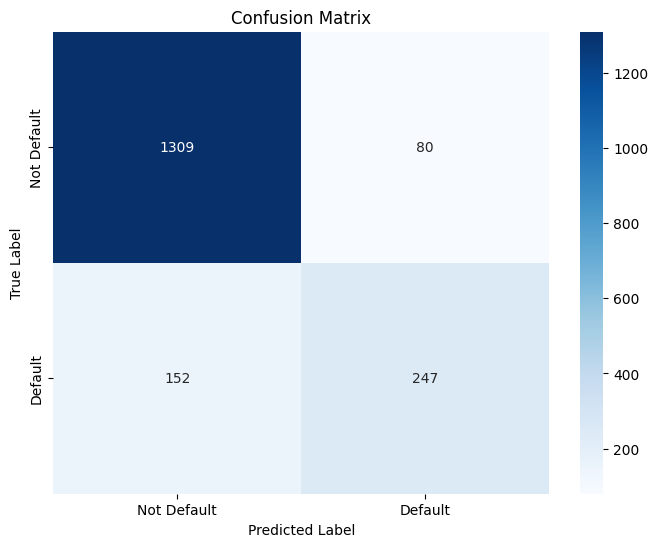


Accuracy: 0.8702
Precision: 0.7554
Recall: 0.6190
F1-Score: 0.6804

Classification Report:
                 precision    recall  f1-score   support

Not Default (0)       0.90      0.94      0.92      1389
    Default (1)       0.76      0.62      0.68       399

       accuracy                           0.87      1788
      macro avg       0.83      0.78      0.80      1788
   weighted avg       0.86      0.87      0.87      1788



In [2]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Model Evaluation ---

# Make predictions on the test data
y_pred = decision_tree.predict(X_test)

# --- Confusion Matrix ---
print("--- Model Evaluation ---")
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_matrix)

# For a more visual representation of the confusion matrix:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Default', 'Default'], yticklabels=['Not Default', 'Default'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# --- Key Performance Metrics ---

# Accuracy: The proportion of correctly classified instances.
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Precision: The ability of the classifier not to label a negative sample as positive.
# For the 'Default' class (1): Out of all predictions for 'Default', how many were correct?
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Recall (Sensitivity): The ability of the classifier to find all the positive samples.
# For the 'Default' class (1): Out of all actual 'Default' cases, how many did the model correctly identify?
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# F1-Score: The weighted average of Precision and Recall. It's a good balance between them.
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")


# --- Classification Report ---
# This report provides a comprehensive summary of the performance for each class.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Default (0)', 'Default (1)']))

In [3]:
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(n_estimators=100, random_state=42)

In [4]:
modelRF.fit(X_train,y_train)
y_pred1 = modelRF.predict(X_test)
# y_pred_proba = modelRF.predict_proba(X_test) 
print(f"yp1 :{len(y_pred1)} ,y_test : {len(y_test)}")

yp1 :1788 ,y_test : 1788


In [5]:

accuracy1 = accuracy_score(y_test, y_pred1)
print(f"\nAccuracy: {(accuracy1)}")


Accuracy: 0.9026845637583892


In [8]:
import joblib

# Suppose rf is your trained RandomForest model
joblib.dump(modelRF, "../models/modelRF.pkl")


['../models/modelRF.pkl']

In [10]:
def predict_loan_default(loan, mortdue, value, reason, job, yoj, derog, delinq, clage, ninq, clno, debtinc):
    """
    Predicts loan default based on input features.

    Args:
        All arguments are single values for the corresponding features.

    Returns:
        A string indicating 'Default' or 'Not Default'.
    """
    # Create a DataFrame from the input
    input_data = pd.DataFrame({
        'LOAN': [loan],
        'MORTDUE': [mortdue],
        'VALUE': [value],
        'REASON': [reason],
        'JOB': [job],
        'YOJ': [yoj],
        'DEROG': [derog],
        'DELINQ': [delinq],
        'CLAGE': [clage],
        'NINQ': [ninq],
        'CLNO': [clno],
        'DEBTINC': [debtinc]
    })

    # Impute and encode the input data using the same imputers and encoder
    input_data[numerical_features] = numerical_imputer.transform(input_data[numerical_features])
    input_data[categorical_features] = categorical_imputer.transform(input_data[categorical_features])

    input_encoded = pd.DataFrame(encoder.transform(input_data[categorical_features]))
    input_encoded.columns = encoder.get_feature_names_out(categorical_features)

    input_data = input_data.drop(categorical_features, axis=1)
    input_data = pd.concat([input_data, input_encoded], axis=1)

    # Reorder columns to match the training data
    input_data = input_data[X_train.columns]


    # Make the prediction
    prediction = modelRF.predict(input_data)

    if prediction[0] == 1:
        return "Prediction: **Default**"
    else:
        return "Prediction: **Not Default**"

# --- Example Usage ---

# Provide some example values to test the prediction function
loan_amount = 20000
mortgage_due = 75000
property_value = 100000
reason_for_loan = 'DebtCon'
job_type = 'ProfExe'
years_on_job = 10
derogatory_reports = 0
delinquent_lines = 0
age_of_oldest_line = 180
recent_inquiries = 1
num_credit_lines = 25
debt_to_income = 35

# Get the prediction
prediction_result = predict_loan_default(
    loan=loan_amount,
    mortdue=mortgage_due,
    value=property_value,
    reason=reason_for_loan,
    job=job_type,
    yoj=years_on_job,
    derog=derogatory_reports,
    delinq=delinquent_lines,
    clage=age_of_oldest_line,
    ninq=recent_inquiries,
    clno=num_credit_lines,
    debtinc=debt_to_income
)

print(prediction_result)

Prediction: **Not Default**


In [13]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import joblib

# Example training DataFrame (replace with your actual dataset)
# df = pd.read_csv("your_data.csv")
# X = df.drop("TARGET", axis=1)
# y = df["TARGET"]

# Define feature types
numeric_features = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ',
                    'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
categorical_features = ['REASON', 'JOB']

# Numeric preprocessing: fill missing with mean
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Categorical preprocessing: one-hot encode missing as "missing"
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Full pipeline: preprocessing + model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Fit pipeline
model.fit(X, y)

# Save pipeline
joblib.dump(model, "model/modelN.pkl")


ValueError: A given column is not a column of the dataframe

In [11]:
import joblib

# Suppose rf is your trained RandomForest model
joblib.dump(modelRF, "../models/modelRF.pkl")


['../models/modelRF.pkl']